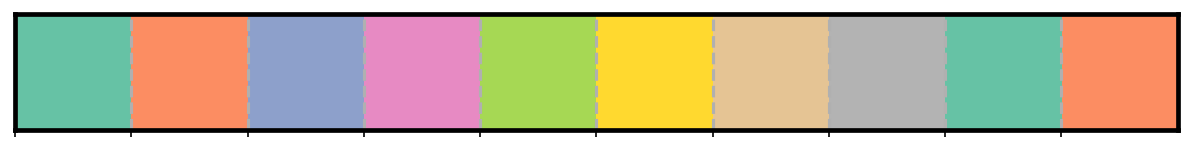

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from iminuit import Minuit
from scipy import stats
from iminuit import cost
from scipy import integrate
import scipy
import matplotlib



def setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150):
    """
    Global plotting setup with grey background and custom styling
    """

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    # --- Background color ---
    plt.rcParams['axes.facecolor'] = "#e8e8e8"

    # --- Fonts ---
    rc = {"font.family": "serif", 
          "mathtext.fontset": "stix"}
    plt.rcParams.update(rc)
    plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
    
    plt.rcParams.update({
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Color palette ---
    colors = sns.color_palette("Set2", 10)
    sns.set_palette(colors)
    sns.palplot(colors)
    plt.show()

    return colors




def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
colors = setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150)

In [119]:
data1 = np.genfromtxt("LLH_Ratio_2_data.txt")
data2 = np.genfromtxt("LLH_Ratio_2a_data.txt")
data1 = data1[:,0]
data2 = data2[:,0]

In [120]:
def func(x, a, b):
    return 1 + a*x + b*x**2

def pdf_func(x, a, b):
    norm, _ = integrate.quad(lambda x: func(x, a, b), -1, 1)
    return func(x, a, b) / norm

def ln_likelihood(vals, func, a, b):
    pdf_vals = pdf_func(vals,a,b)
    return -np.sum(np.log(pdf_vals))

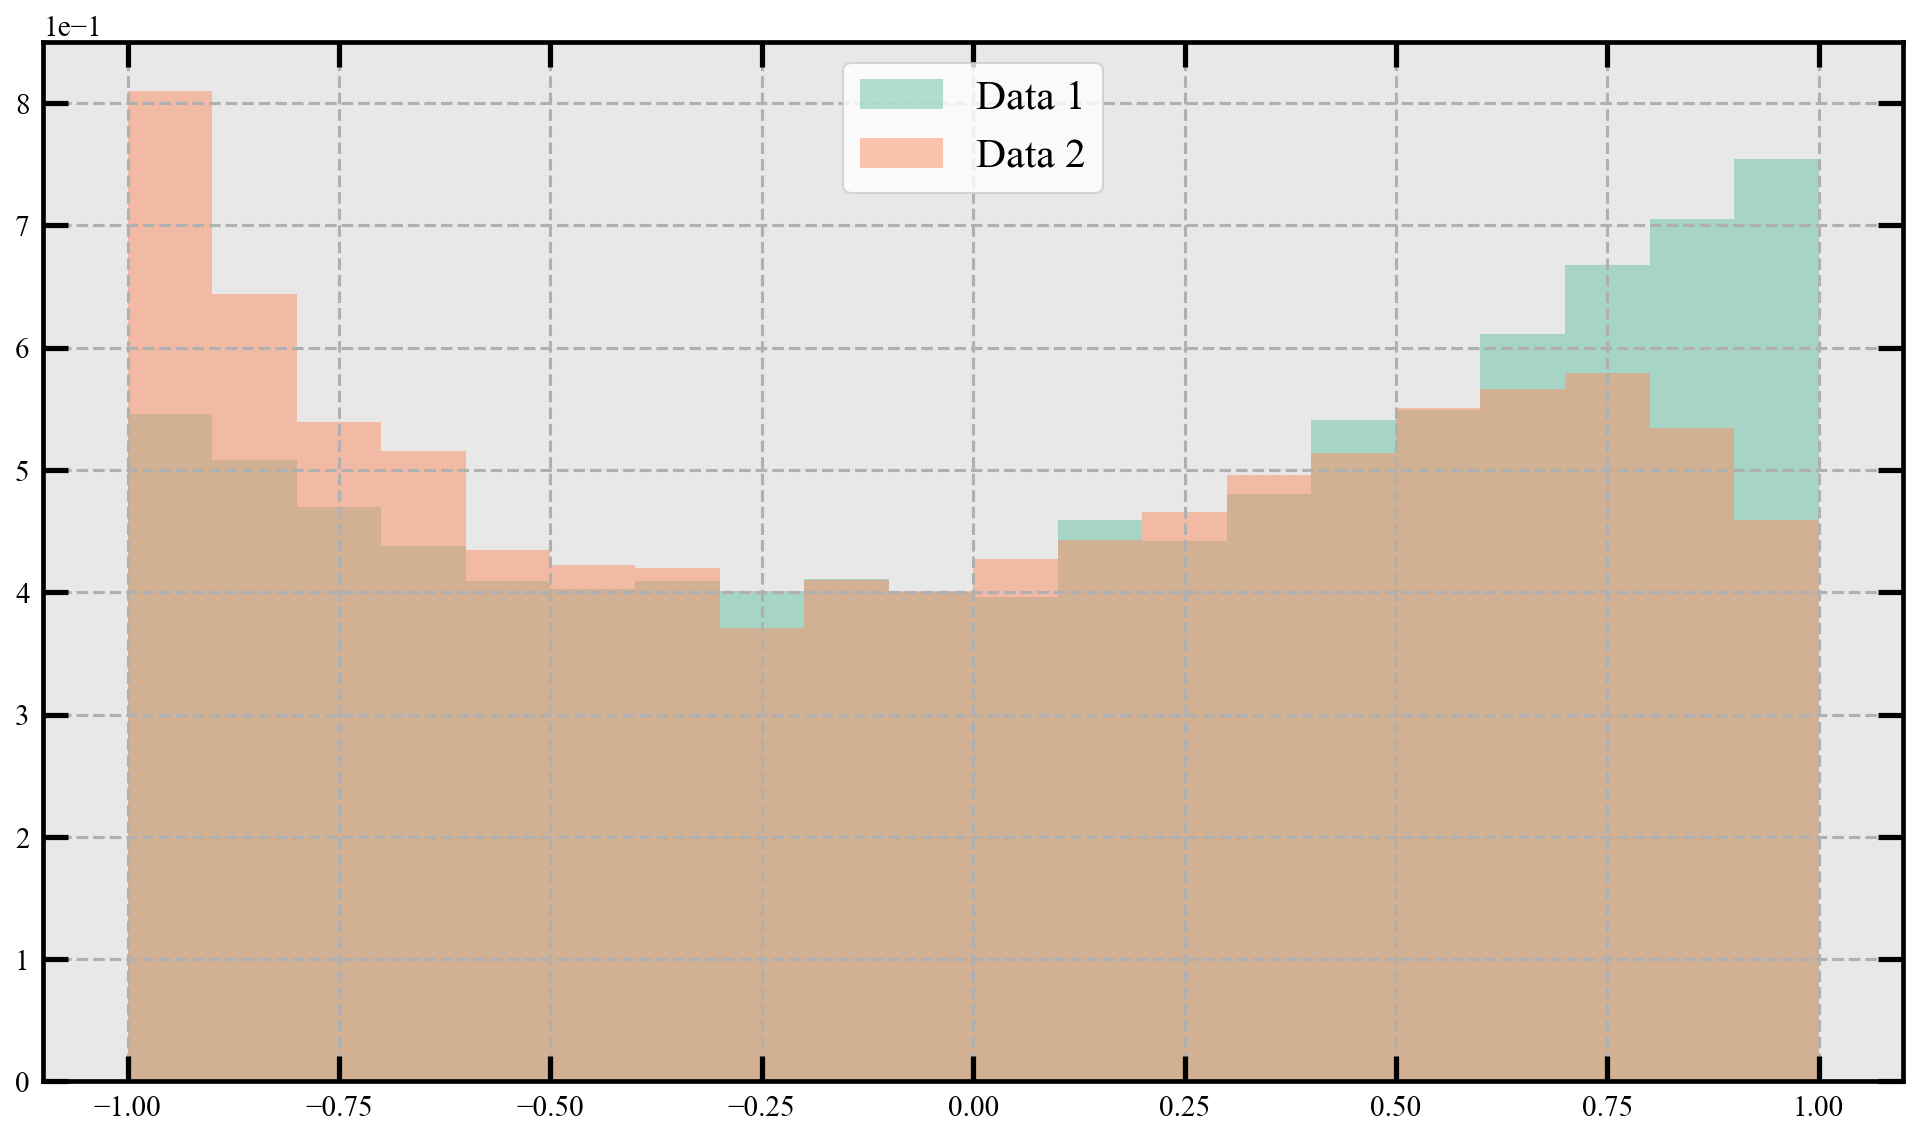

In [121]:
Nbins=20
x_range = (-1,1)
counts1,edges1 = np.histogram(data1, bins=Nbins, range=x_range, density=True)
counts2,edges2 = np.histogram(data2, bins=Nbins, range=x_range, density=True)

fig, ax = plt.subplots()
ax.hist(data1, bins=Nbins, range=x_range, alpha=0.5, label="Data 1", density=True)
ax.hist(data2, bins=Nbins, range=x_range, alpha=0.5, label="Data 2", density=True)
ax.legend()
stylize_ticks(fig, ax)
plt.show()

In [122]:
ullhfit1 = cost.UnbinnedNLL(data1, pdf_func)
m = Minuit(lambda a,b: ln_likelihood(data1, pdf_func, a, b), a=1, b=1)
mfit_ullh1 = Minuit(ullhfit1, a=1, b=1)
mfit_ullh1.migrad()



┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.686e+04                  │              Nfcn = 55               │
│ EDM = 1.7e-07 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.299   │   0.016   │            │            │         │         │       │
│ 1 │ b    │   0.66    │   0.04    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 0.000264  0.16e-3 │
│ b │  0.16e-3   0.0013 │
└───┴───────────────────┘

In [123]:
ullhfit2 = cost.UnbinnedNLL(data2, pdf_func)
mfit_ullh2 = Minuit(ullhfit2, a=1, b=1)
mfit_ullh2.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.73e+04                   │              Nfcn = 64               │
│ EDM = 3.46e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │  -0.043   │   0.015   │            │            │         │         │       │
│ 1 │ b    │   0.580   │   0.035   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 0.000239  0.03e-3 │
│ b │  0.03e-3  0.00123 │
└───┴───────────────────┘

In [124]:
m = Minuit(lambda a,b: ln_likelihood(data1, pdf_func, a, b), a=1, b=1)
m.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.343e+04                  │              Nfcn = 57               │
│ EDM = 8.52e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.299   │   0.023   │            │            │         │         │       │
│ 1 │ b    │   0.66    │   0.05    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 0.000528   0.3e-3 │
│ b │   0.3e-3  0.00261 │
└───┴───────────────────┘

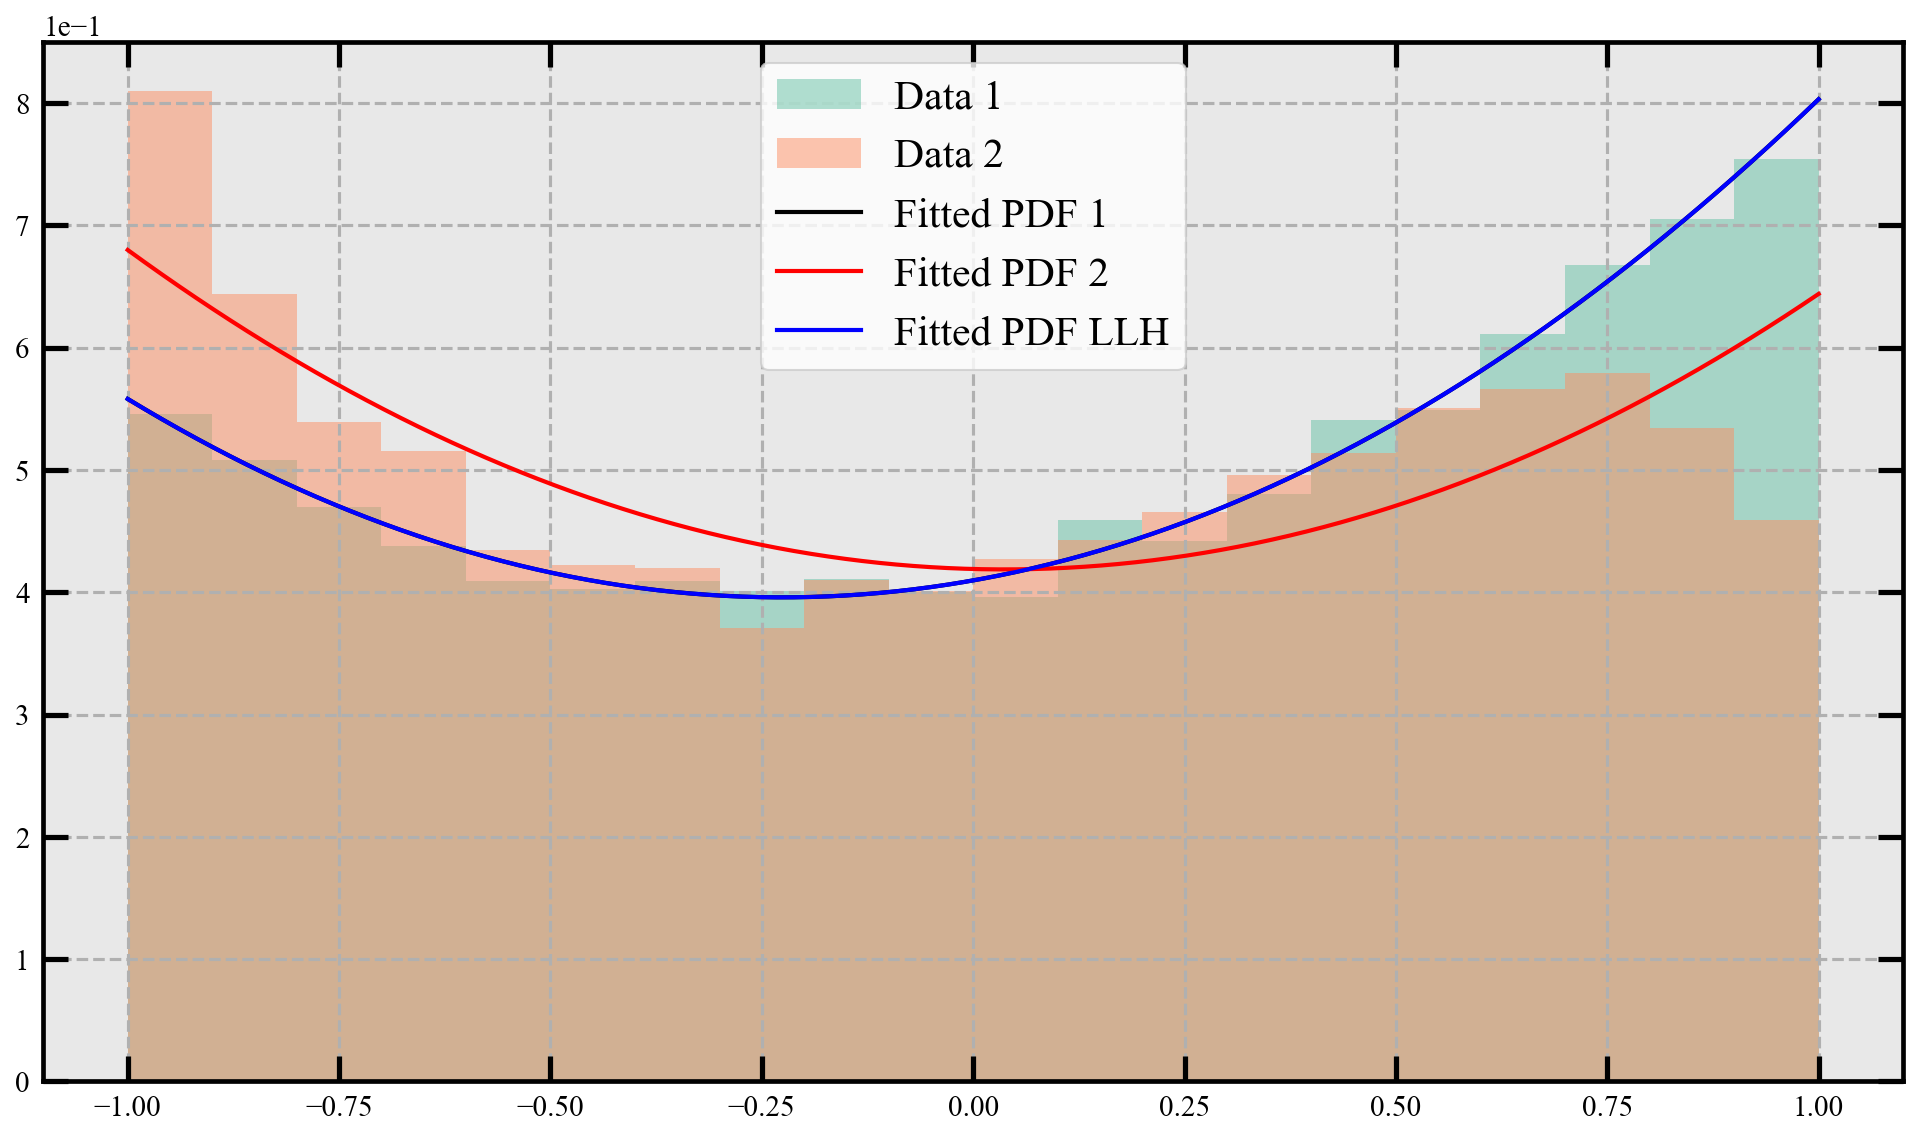

In [125]:
Nbins=20
x_range = (-1,1)
counts1,edges1 = np.histogram(data1, bins=Nbins, range=x_range, density=True)
counts2,edges2 = np.histogram(data2, bins=Nbins, range=x_range, density=True)
x_axis = np.linspace(x_range[0], x_range[1], 100)
pdf_fit1 = pdf_func(x_axis, mfit_ullh1.values["a"], mfit_ullh1.values["b"])
pdf_fit2 = pdf_func(x_axis, mfit_ullh2.values["a"], mfit_ullh2.values["b"])
pdf_fit3 = pdf_func(x_axis, m.values["a"], m.values["b"])

fig, ax = plt.subplots()
ax.hist(data1, bins=Nbins, range=x_range, alpha=0.5, label="Data 1", density=True)
ax.hist(data2, bins=Nbins, range=x_range, alpha=0.5, label="Data 2", density=True)
ax.plot(x_axis, pdf_fit1, label="Fitted PDF 1", color="black", linewidth=2)
ax.plot(x_axis, pdf_fit2, label="Fitted PDF 2", color="red", linewidth=2)
ax.plot(x_axis, pdf_fit3, label="Fitted PDF LLH", color="blue", linewidth=2)
ax.legend()
stylize_ticks(fig, ax)
plt.show()

In [126]:
N = 1000 #create 1000 datasets
N_points = 2000 # number of points in each dataset
simulated_datasets1 = []
for _ in range(N):
    dataset = np.array([])
    while len(dataset) < N_points:
        x = np.random.uniform(-1, 1)
        u = np.random.uniform(0, 1)
        if u < pdf_func(x, mfit_ullh1.values['a'], mfit_ullh1.values['b']):
            dataset = np.append(dataset, x)
    simulated_datasets1.append(dataset)

simulated_datasets2 = []
for _ in range(N):
    dataset = np.array([])
    while len(dataset) < N_points:
        x = np.random.uniform(-1, 1)
        u = np.random.uniform(0, 1)
        if u < pdf_func(x, mfit_ullh2.values['a'], mfit_ullh2.values['b']):
            dataset = np.append(dataset, x)
    simulated_datasets2.append(dataset)

In [127]:
simulated_datasets1 = np.array(simulated_datasets1)
simulated_datasets2 = np.array(simulated_datasets2)
a_trials = np.zeros(N)
b_trials = np.zeros(N)

for i, dataset in enumerate(simulated_datasets1):
    ullhfit = cost.UnbinnedNLL(dataset, pdf_func)
    mfit = Minuit(ullhfit, a=1, b=1)
    mfit.migrad()
    a_trials[i] = mfit.values['a']
    b_trials[i] = mfit.values['b']

a_trials2 = np.zeros(N)
b_trials2 = np.zeros(N)
for i, dataset in enumerate(simulated_datasets2):
    ullhfit = cost.UnbinnedNLL(dataset, pdf_func)
    mfit = Minuit(ullhfit, a=1, b=1)
    mfit.migrad()
    a_trials2[i] = mfit.values['a']
    b_trials2[i] = mfit.values['b']

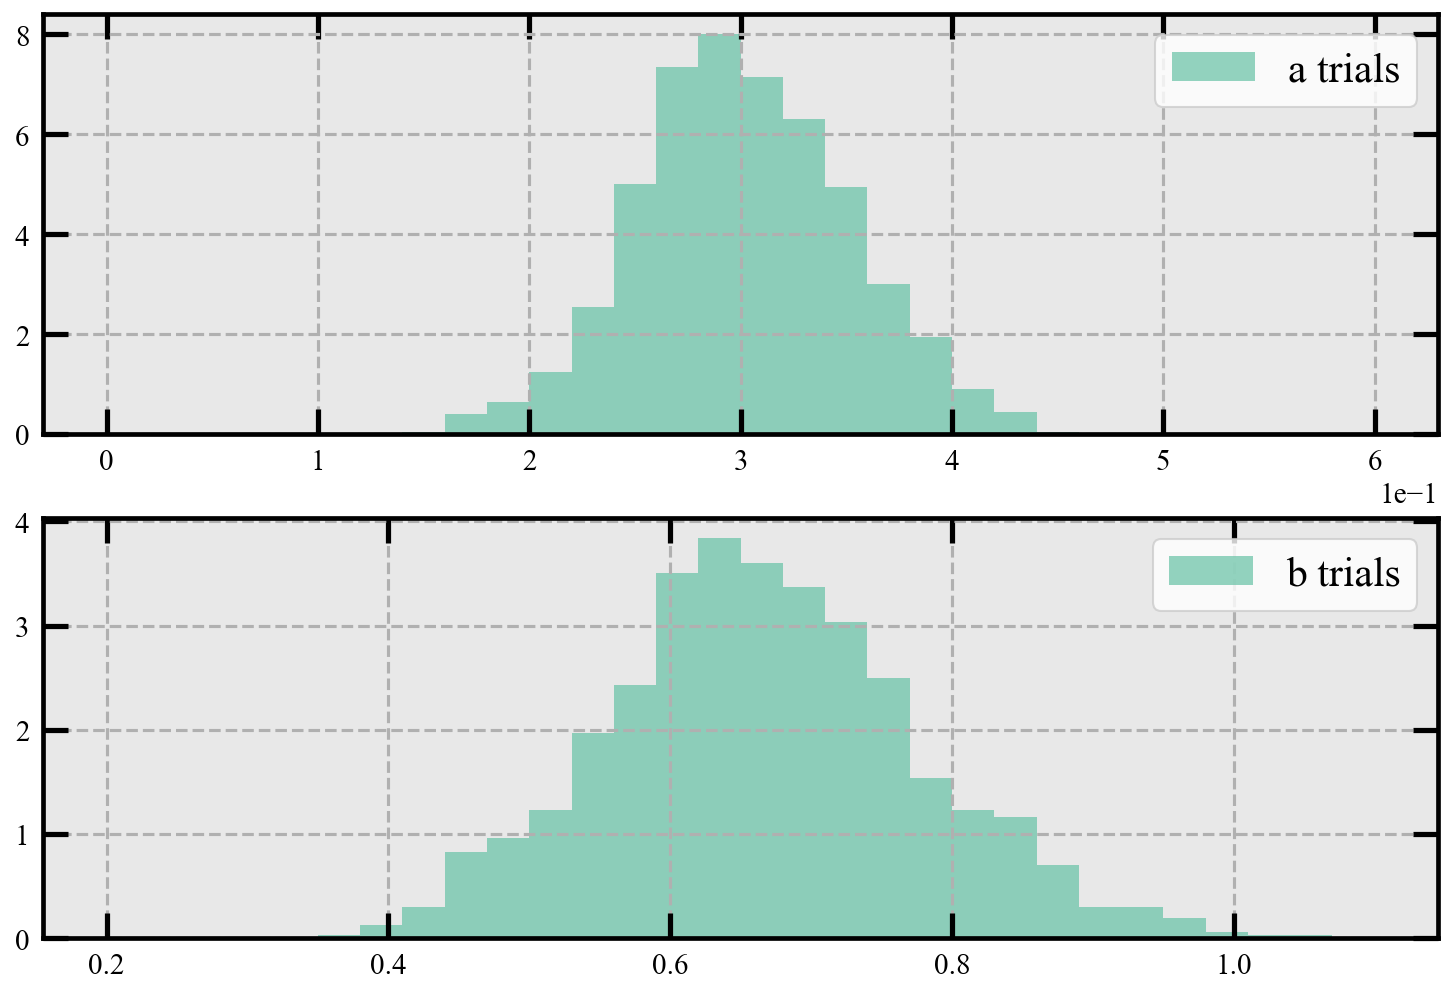

In [128]:
Nbins=30
a_range = (0,0.6)
b_range = (0.2,1.1)
fig, ax = plt.subplots(2,1, figsize=(12, 8))
ax[0].hist(a_trials, bins=Nbins, range=a_range, alpha=0.7, label="a trials", density=True)
ax[1].hist(b_trials, bins=Nbins, range=b_range, alpha=0.7, label="b trials", density=True)
ax[0].legend()
ax[1].legend()
stylize_ticks(fig, ax[0])
stylize_ticks(fig, ax[1])
plt.show()


In [129]:
like = np.zeros(N)
for i in range(N):
    like[i] = ln_likelihood(data1, pdf_func, a_trials[i], b_trials[i])

# Compare to the best fit on the SAME simulated data
best_like = np.min(like)
print("Best likelihood:", best_like)
print('min like:', np.min(like))
like_diff = like - best_like

Best likelihood: 13432.145541822501
min like: 13432.145541822501


In [133]:
like2 = np.zeros(N)
for i in range(N):
    like2[i] = ln_likelihood(data2, pdf_func, a_trials2[i], b_trials2[i])
like_diff2 = like2 - np.min(like2)

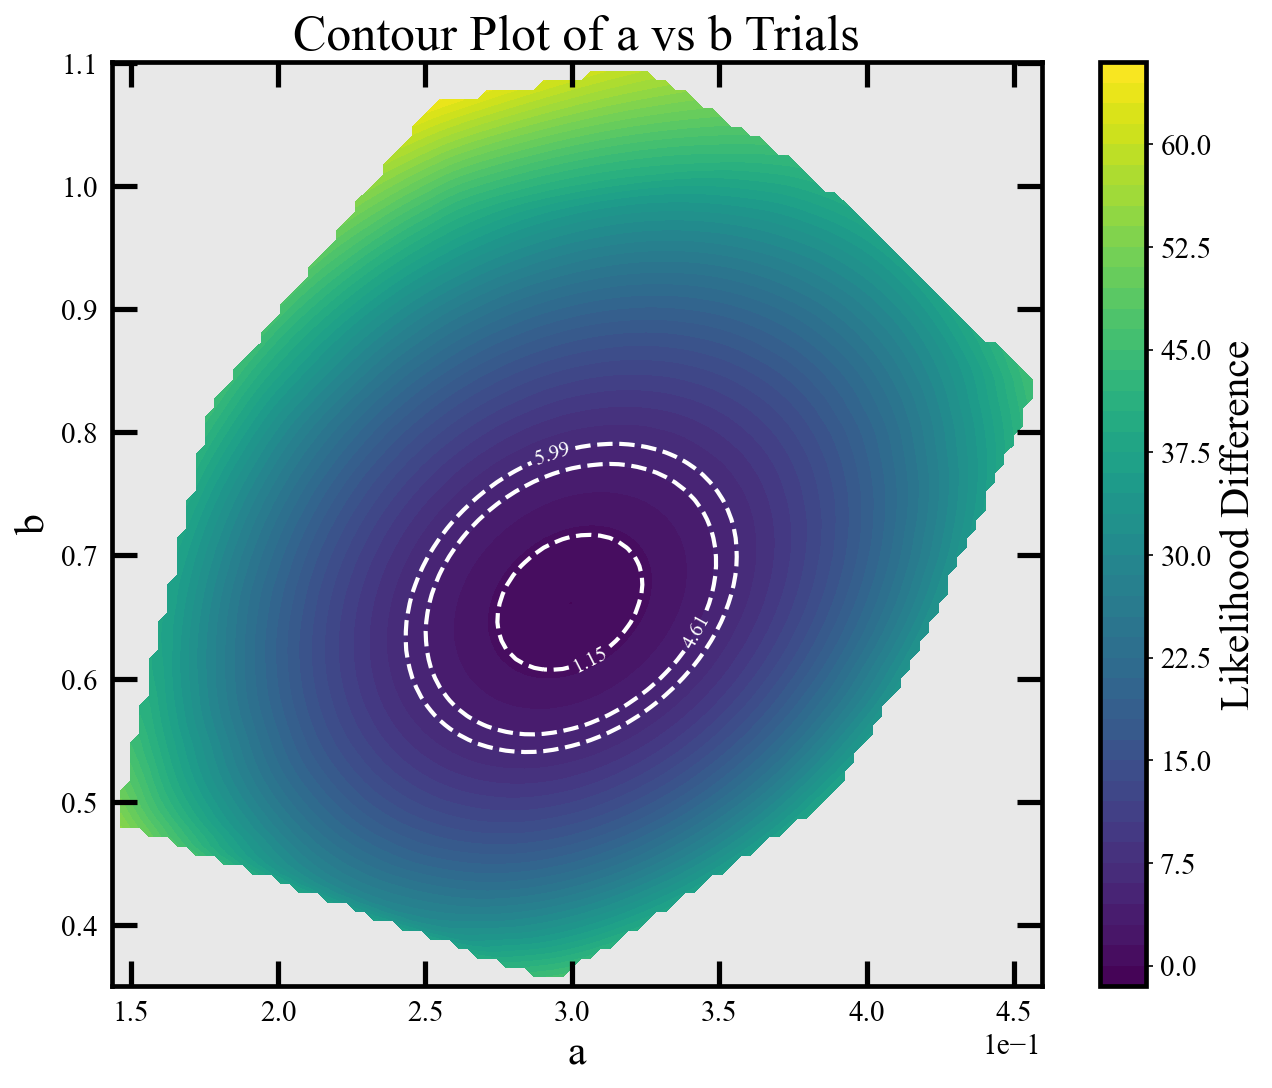

In [131]:
from scipy.interpolate import griddata

# Create a regular grid
a_grid = np.linspace(a_trials.min(), a_trials.max(), 100)
b_grid = np.linspace(b_trials.min(), b_trials.max(), 100)
A, B = np.meshgrid(a_grid, b_grid)

# Interpolate like_diff onto the grid
points = np.column_stack([a_trials, b_trials])
Z = griddata(points, like_diff, (A, B), method='cubic')

# Create contour plot
fig, ax = plt.subplots(figsize=(10, 8))
contour = ax.contourf(A, B, Z, levels=50, cmap="viridis")
fig.colorbar(contour, ax=ax, label="Likelihood Difference")

#levels = [ np.percentile(like_diff, 50), np.percentile(like_diff, 90), np.percentile(like_diff, 95)]
#print("Contour levels (50th, 90th, 95th percentiles):", levels)
levels = [1.15, 4.61, 5.99]
contour = ax.contour(A, B, Z, levels=levels, colors='white', linewidths=2, linestyles='--')
ax.clabel(contour, inline=True, fontsize=10)

ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_title("Contour Plot of a vs b Trials")
#fig.colorbar(contour, ax=ax, label="Likelihood Difference")
stylize_ticks(fig, ax)
plt.grid(False)
plt.show()

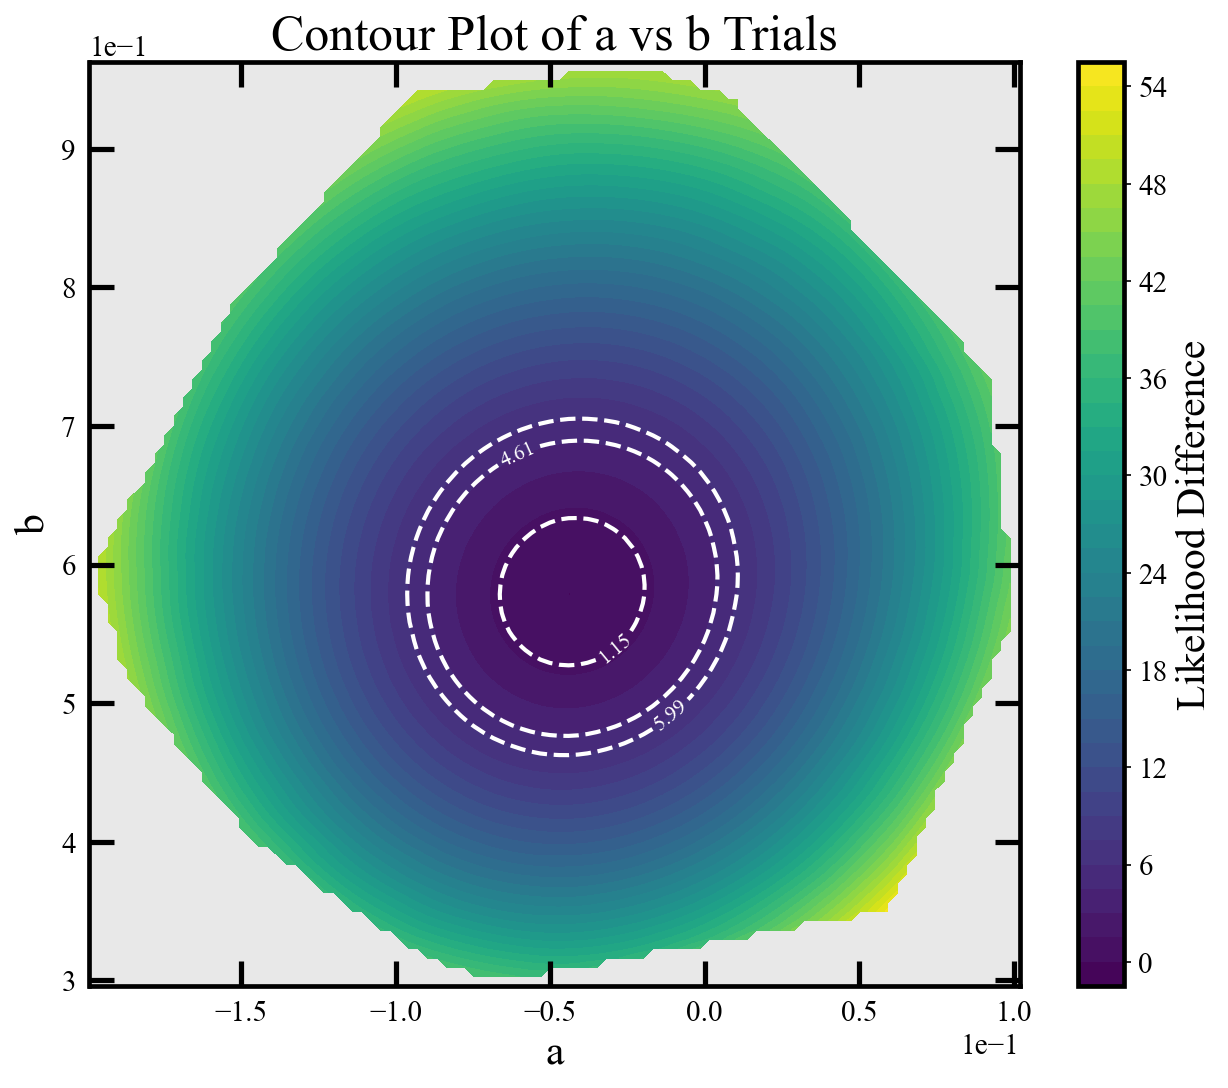

In [134]:
a_grid2 = np.linspace(a_trials2.min(), a_trials2.max(), 100)
b_grid2 = np.linspace(b_trials2.min(), b_trials2.max(), 100)
A, B = np.meshgrid(a_grid2, b_grid2)

# Interpolate like_diff onto the grid
points = np.column_stack([a_trials2, b_trials2])
Z = griddata(points, like_diff2, (A, B), method='cubic')

# Create contour plot
fig, ax = plt.subplots(figsize=(10, 8))
contour = ax.contourf(A, B, Z, levels=50, cmap="viridis")
fig.colorbar(contour, ax=ax, label="Likelihood Difference")

#levels = [ np.percentile(like_diff, 50), np.percentile(like_diff, 90), np.percentile(like_diff, 95)]
#print("Contour levels (50th, 90th, 95th percentiles):", levels)
levels = [1.15, 4.61, 5.99]
contour = ax.contour(A, B, Z, levels=levels, colors='white', linewidths=2, linestyles='--')
ax.clabel(contour, inline=True, fontsize=10)

ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_title("Contour Plot of a vs b Trials")
#fig.colorbar(contour, ax=ax, label="Likelihood Difference")
stylize_ticks(fig, ax)
plt.grid(False)
plt.show()